# Thermal Stresses in a Flat Plate

To derive the thermal stress components $\sigma_x$, $\sigma_y$, and $\sigma_z$ in a flat plate (slab) subjected to a one-dimensional temperature gradient $T(x)$, we combine the fundamental equations of solid mechanics: **equilibrium**, **compatibility**, and **constitutive laws**.

---

## Out-of-Plane Stress ($\sigma_x$)
From the local **equilibrium equation** in the absence of body forces:
$$\frac{d\sigma_x}{dx} = 0 \implies \sigma_x = \text{constant}$$

Since the surfaces of the plate at $x=0$ and $x=L$ are free of external pressure (traction-free), the boundary conditions are $\sigma_x(0) = 0$ and $\sigma_x(L) = 0$. Therefore, for a plate under a thermal gradient:
$$\sigma_x(x) = 0$$

Unlike in a cylinder where curvature generates radial stress, a flat plate does not develop stresses normal to its surface under a 1D thermal gradient.

---

## In-Plane Stresses ($\sigma_y$ and $\sigma_z$)
For an infinite or highly constrained plate, we assume symmetry in the plane, thus $\sigma_y(x) = \sigma_z(x) = \sigma(x)$.

### Constitutive Equation (Hooke's Law)
The total strain $\epsilon_y$ consists of elastic strain and thermal expansion:
$$\epsilon_y(x) = \frac{1}{E}[\sigma_y - \nu(\sigma_x + \sigma_z)] + \alpha \Delta T(x)$$
Given $\sigma_x = 0$ and $\sigma_y = \sigma_z = \sigma$, this simplifies to:
$$\epsilon_y(x) = \frac{1-\nu}{E}\sigma(x) + \alpha \Delta T(x)$$
*Note: $\Delta T(x) = T(x) - T_{ref}$ is the change relative to the stress-free reference temperature.*

### Compatibility and the Bernoulli Hypothesis
The **Euler-Bernoulli hypothesis** is a restriction on the **displacement field** $u_y(x, y)$.
If the plate length is $L$, We define the longitudinal displacement as:
$$u_y(x, y) = v_0(y) - (x-L/2) \cdot \frac{dw(y)}{dy}$$

Taking the derivative to find the strain:
$$\epsilon_y(x) = \frac{\partial u_y}{\partial y} = \underbrace{\frac{dv_0}{dy}}_{\epsilon_0} - x \cdot \underbrace{\frac{d^2w}{dy^2}}_{\kappa}$$

This leads to the **linear strain distribution**:
$$\epsilon_y(x) = \epsilon_0 - \kappa (x-L/2)$$

Internal stresses arise because the material's "desire" to expand non-linearly ($\alpha \Delta T(x)$) is blocked by the geometric requirement to remain plane ($\epsilon_0 - \kappa x$).



---

## Global Equilibrium and Final Solution
By combining the constitutive and compatibility equations:
$$\sigma(x) = \frac{E}{1-\nu} \left[ \epsilon_0 - \kappa (x-L/2) - \alpha \Delta T(x) \right]$$

Since the plate is free from external loads, we solve for $\epsilon_0$ and $\kappa$ by enforcing:
* **Zero Resultant Force:** $\int_{0}^{L} \sigma(x) dx = 0$
* **Zero Resultant Moment:** $\int_{0}^{L} \sigma(x) \cdot (x - L/2) \, dx = 0$

For a plate of thickness $L$, the final stress distribution is:
$$\sigma_y(x) = \sigma_z(x) = \frac{\alpha E}{1-\nu} \left[ \underbrace{\frac{1}{L} \int_{0}^{L} T(x) dx}_{\text{Mean Temperature}} + \underbrace{\frac{12(x - L/2)}{L^3} \int_{0}^{L} T(x) (x - L/2) dx}_{\text{Thermal Bending}} - T(x) \right]$$

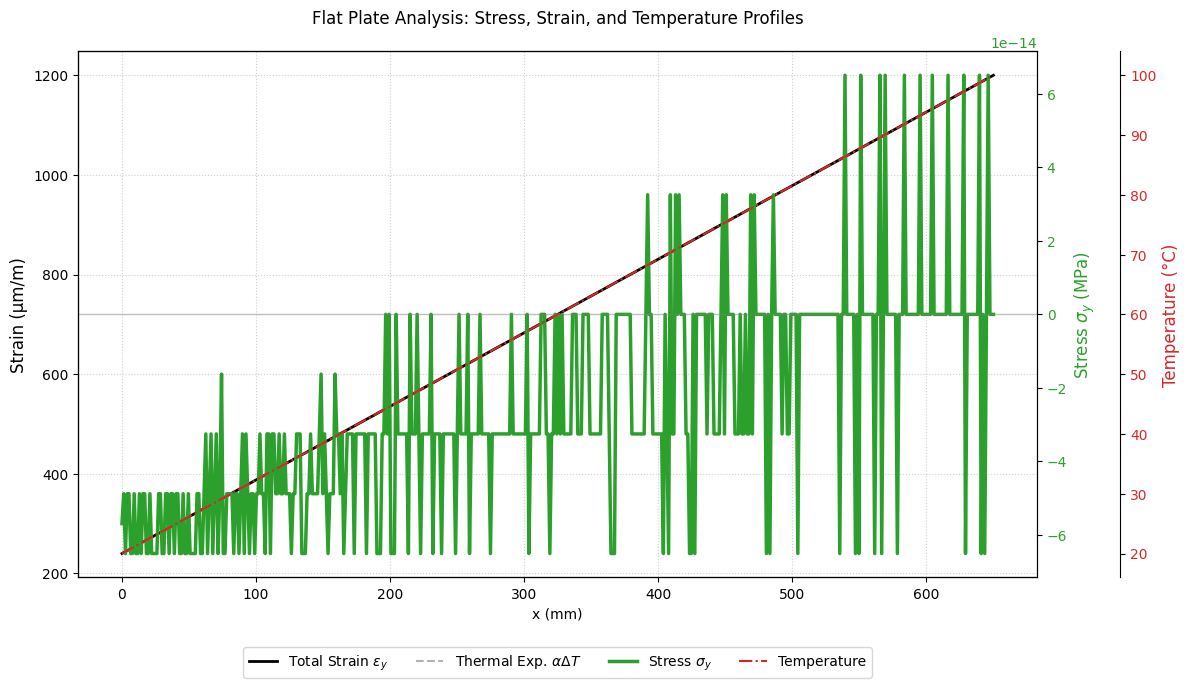

Membrane Strain (epsilon_0): 720.00 µm/m
Curvature (kappa): 1476.9231 µm/m^2


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import quad

# --- Material and Geometry Parameters ---
L = 0.650       # Thickness (m)
E = 210e9       # Young's Modulus (Pa)
nu = 0.3        # Poisson's ratio
alpha = 1.2e-5  # Thermal expansion (1/K)
x = np.linspace(0, L, 500)

# --- 1. Temperature Profile ---
Ti_val, Te_val, Tmin = 100.0, 100.0, 20.0
x_mid = 2 * L / 3
k_temp = (Ti_val - Tmin) / (0 - x_mid)**2

def T_profile(x_coord):
    # return Tmin + k_temp * (x_coord - x_mid)**2
    return Tmin + x_coord * (Ti_val - Tmin) / L  # Linear profile for simplicity

# --- 2. Calculate Membrane Strain (epsilon_0) and Curvature (kappa) ---
# For a free plate, epsilon_y(x) = epsilon_0 + kappa*(x - L/2)
# epsilon_0 = (alpha/L) * integral(T dx)
# kappa = (12*alpha/L^3) * integral(T * (x - L/2) dx)

T_int, _ = quad(T_profile, 0, L)
epsilon_0 = (alpha / L) * T_int

M_int, _ = quad(lambda x_c: T_profile(x_c) * (x_c - L/2), 0, L)
kappa = (12 * alpha / L**3) * M_int

# --- 3. Compute Strain and Stress ---
thermal_strain = alpha * T_profile(x)
total_strain = epsilon_0 + kappa * (x - L/2)
# Stress arises from the difference between compatible strain and thermal expansion
sigma_y = (E / (1 - nu)) * (total_strain - thermal_strain)

# --- 4. Plotting ---
fig, ax1 = plt.subplots(figsize=(12, 7))

# Primary Axis: Strain
color_strain = 'black'
ax1.set_xlabel('x (mm)')
ax1.set_ylabel(r'Strain (µm/m)', color=color_strain, fontsize=12)
ax1.plot(x * 1e3, total_strain * 1e6, color=color_strain, lw=2, label=r'Total Strain $\epsilon_y$')
ax1.plot(x * 1e3, thermal_strain * 1e6, 'k--', alpha=0.3, label=r'Thermal Exp. $\alpha \Delta T$')
ax1.tick_params(axis='y', labelcolor=color_strain)
ax1.grid(True, linestyle=':', alpha=0.6)

# Secondary Axis: Stress
ax2 = ax1.twinx()
color_stress = 'tab:green'
ax2.set_ylabel(r'Stress $\sigma_y$ (MPa)', color=color_stress, fontsize=12)
ax2.plot(x * 1e3, sigma_y / 1e6, color=color_stress, lw=2.5, label=r'Stress $\sigma_y$')
ax2.tick_params(axis='y', labelcolor=color_stress)
ax2.axhline(0, color='gray', lw=1, alpha=0.5)

# Tertiary Axis: Temperature
ax3 = ax1.twinx()
# Offset the right spine to make room for the third axis
ax3.spines['right'].set_position(('outward', 60))
color_temp = 'tab:red'
ax3.set_ylabel('Temperature (°C)', color=color_temp, fontsize=12)
ax3.plot(x * 1e3, T_profile(x), color=color_temp, ls='-.', lw=1.5, label='Temperature')
ax3.tick_params(axis='y', labelcolor=color_temp)

plt.title('Flat Plate Analysis: Stress, Strain, and Temperature Profiles', pad=20)

# Combining legends
lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
lines3, labels3 = ax3.get_legend_handles_labels()
ax1.legend(lines + lines2 + lines3, labels + labels2 + labels3, loc='upper center', bbox_to_anchor=(0.5, -0.12), ncol=4)

plt.tight_layout()
plt.show()

print(f"Membrane Strain (epsilon_0): {epsilon_0*1e6:.2f} µm/m")
print(f"Curvature (kappa): {kappa*1e6:.4f} µm/m^2")